# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
    # Cantidad de valores nulos
print('Cantidad de valores nulos:')
print(users.isna().sum())
    # Salto de line
print()
    # Proporción de valores nulos
print('Proporción de valores nulos:')
print(users.isna().mean())

Cantidad de valores nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
    # Cantidad de valores nulos
print('Cantidad de valores nulos:')
print(usage.isna().sum())
    # Salto de line
print()
    # Proporción de valores nulos
print('Proporción de valores nulos:')
print(usage.isna().mean())

Cantidad de valores nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
     - **En users:**
          - *city*: 11.73%
          - *churn_date*: 88.35%
     - **En usage:**
          - *date*: 0.13%
          - *duration*: 55.19%
          - *length*: 44.74%
  
- Indica qué harías: ¿imputar, eliminar, ignorar?
     - **users.city**: imputar con valor categoric de desconocido ("unknown"); no se pierden datos de usuarios para el análisis general
     - **users.churn_date**: ignorar estas filas; los valores no son "faltantes aleatorios" ya que indica que no ha terminado su interaccion
     - **usage.date**: eliminar estas filas; el impacto es mínimo para el análisis al quitar estas filas
     - **usage.duration**: ignorar nulos; valor solo aplica para la categoría de "*call*" en la columna de "*type*"
     - **usage.length**: ignorar nulos; valor solo aplica para la categoría de "*text*" en la columna de "*type*"

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` tiene números muy estables e indica que son usados par IDs únicos; esto se observa con la diferencia entre min y max es de 4,000 (min: 10,000; max: 13999) mostrando un ID diferente dentro del rango del tamaño.
- La columna `age` muestra que hay mucha variabilidad ya que la desviación estándar esta es mucho mayor a la media (mean: 33.74; std: 123.23). Ademas vemos la existencia de un valor representando faltante visible con el mínimo `-999`

In [13]:
# explorar columnas numéricas de usage
usage[['user_id', 'id', 'duration', 'length']].describe()

,user_id,id,duration,length
count,40000.000000,40000.00000,17924.000000,22104.000000
mean,12002.405975,20000.50000,5.202237,52.127398
std,1157.279564,11547.14972,6.842701,56.611183
min,10000.000000,1.00000,0.000000,0.000000
25%,10996.000000,10000.75000,1.437500,37.000000
50%,12013.000000,20000.50000,3.500000,50.000000
75%,13005.000000,30000.25000,6.990000,64.000000
max,13999.000000,40000.00000,120.000000,1490.000000


- Las columnas `id` y `user_id` tiene números muy estables e indica que son usados par IDs únicos; esto es visible con los valores min y max (`user_id` min: 10,000, max: 13999; `id` min: 1, max: 4000) 
- Las columnas `duration` y `length` muestran que no hay mucha variabilidad  ya que sus respectiva variación estándar y la media son números cercanos ( `duration` mean: 5.2, std: 6.84; `length` mean: 52.13, std: 56.61). Ambas columnas parecen tener outliers en la alta ya que los valores máximos están muy por encima de el percentil del 75% ( `duration` 75%: 6.99, max: 120; `length` 75%: 64, max: 1490)

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` contiene 7 ciudades únicas, donde la mas presente es **Bogota** con una frecuencia de 808 apariciones
- La columna `plan` tiene dos planes únicos, donde el plan mas presente es el **Basico** con una frecuencia de 2595 apariciones

In [15]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` tiene solo dos tipos de identificadores, donde el mas presente es el de **text** con una frecuencia de 22092 apariciones

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
    - Las columna de `age` tiene un valor sentinel representado por `-999`
- ¿Qué acción tomarías?
    - Primero evaluaria su precenci en el dataset y ver porcentaje
    - De hai si es baja el porcentaje los cambiaria por la edad media

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.unique())

[2022 2026 2023 2024]


En `reg_date`, hay cuatro años unicos; de 2022 a 2024, se lata 2025 y tine entradas de 2026

In [19]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.dropna().unique())

[2024.]


En `date`, solo contiene el año de 2024.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
    - La columna de `reg_date` de la tabla `users` contiene el año 2026 como valor, aunque este transcurrindo y se salto el año 2025
- ¿Qué harías con ellas?
    - Como la unica fecha presente en la columna `usage['date']` es 2024 para analisi se puede ignorar la fecha de `users['reg_date']` ya que no hay punto de comparacion en la interseccion de las tablas.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna(). groupby(usage['type']).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna(). groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Diagnostico de nulos en `duration` y `length`: La relacion de nulos entre las columnas de `duration` y `length` son verdaderos MAR ya que si estan completamente relacionados por tipo (`call` o `text`)

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',      # Numero total de mensajes
    'is_call': 'sum',      # Numero total de llamadas
    'duration': 'sum'      # Tiempo total de llamadas
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
plan_distribution = user_profile['plan'].value_counts(normalize=True) * 100

print("Distribución porcentual del tipo de plan (%):")
print(plan_distribution)

Distribución porcentual del tipo de plan (%):
Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

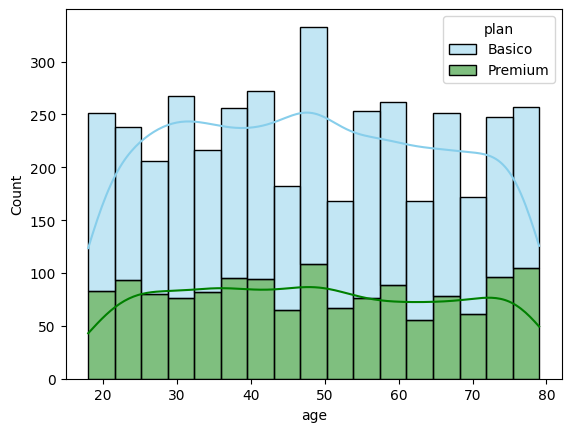

In [48]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile, 
    x='age', 
    hue='plan', 
    palette={'Basico': 'skyblue', 'Premium': 'green'}, 
    multiple='stack', 
    kde=True
)
plt.show()

💡Insights: 
- Distribución pareja etre todas las edades, con una variasion con el pico mas alto en personas al rededor de 50 años y un poco mas usirios jovenes qur mayores para el plan basico.

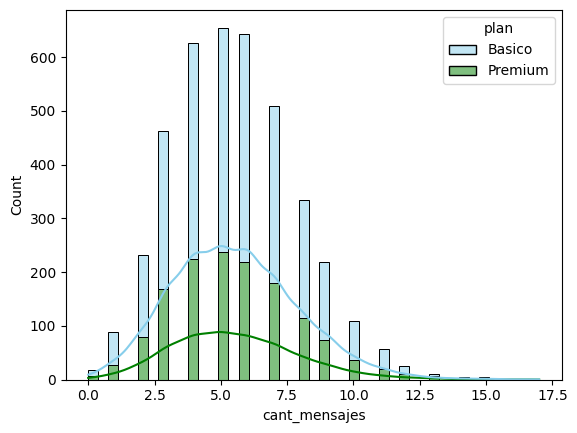

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile, 
    x='cant_mensajes', 
    hue='plan', 
    palette={'Basico': 'skyblue', 'Premium': 'green'}, 
    multiple='stack', 
    kde=True
)
plt.show()

💡Insights: 
- Distribusion de sego a la derecha, donde la mayoria de los usuarion tiene una cantidad cercana a 5 mensaje con algun outlier que se extiende pasando los 15 mensajes.

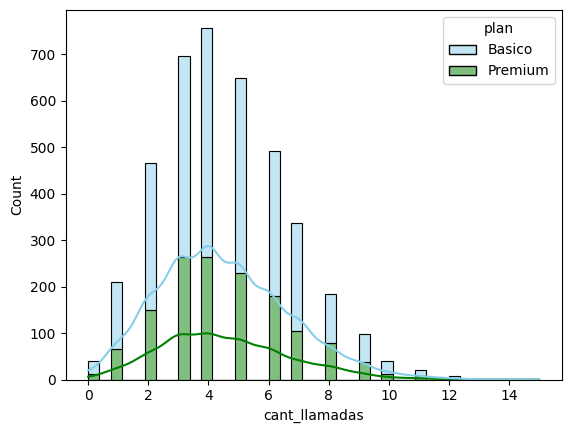

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile, 
    x='cant_llamadas', 
    hue='plan', 
    palette={'Basico': 'skyblue', 'Premium': 'green'}, 
    multiple='stack', 
    kde=True
)
plt.show()

💡Insights: 
- Distribución de sesgo a la derecha para ambos tipos planes, dode los usirios tiene alrededor de 4 llmadas con outliers al rededor de 14 llemadas.

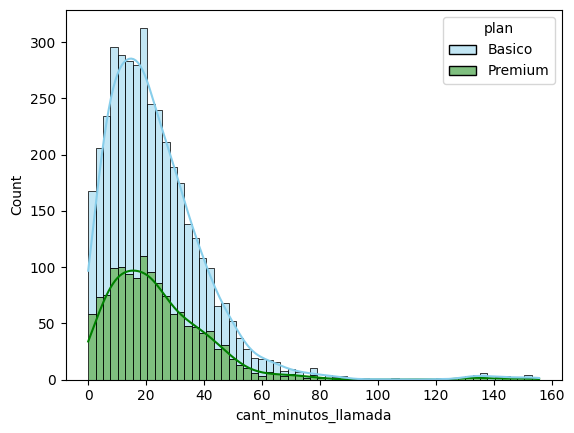

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile, 
    x='cant_minutos_llamada', 
    hue='plan', 
    palette={'Basico': 'skyblue', 'Premium': 'green'}, 
    multiple='stack', 
    kde=True
)
plt.show()

💡Insights: 
- La distribucion tiene un sesgo a la derechea con la mayoria de usuarios concetrados enre los 10 a 30 minutos de llamada, con comportamiento similar para planes basicos y premium. Los outliers tinen un pico visible entre los 130 a 140 minutos llegando casi a los 160 minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

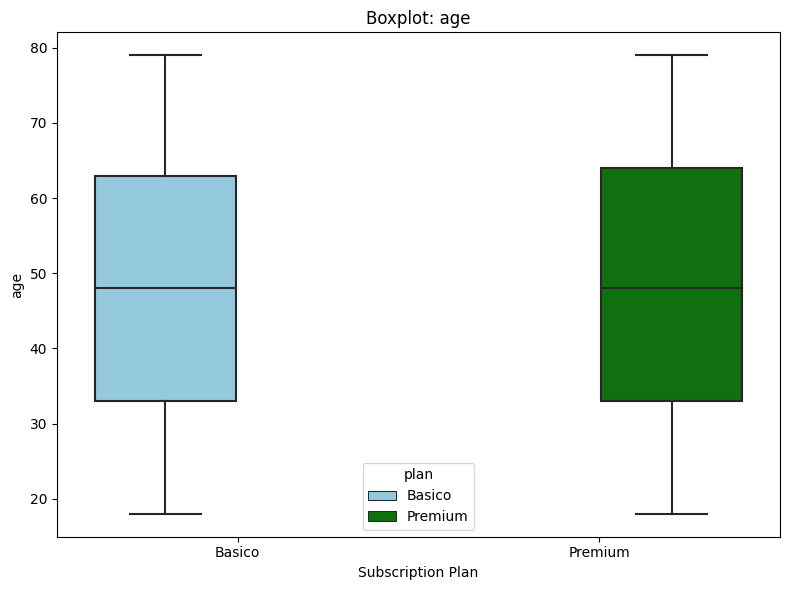

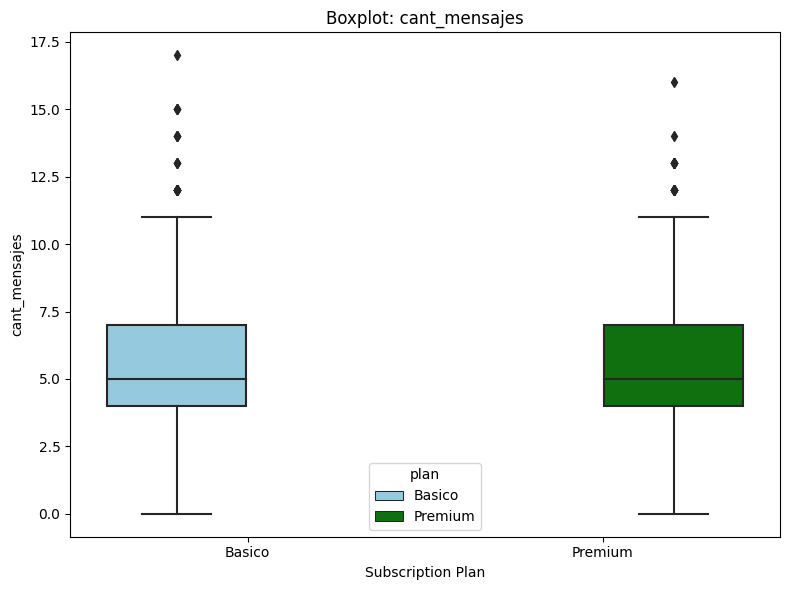

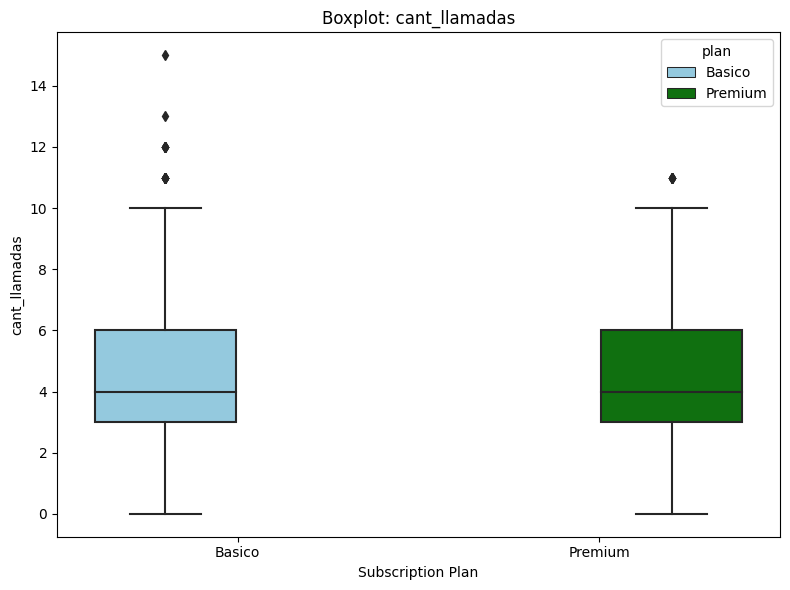

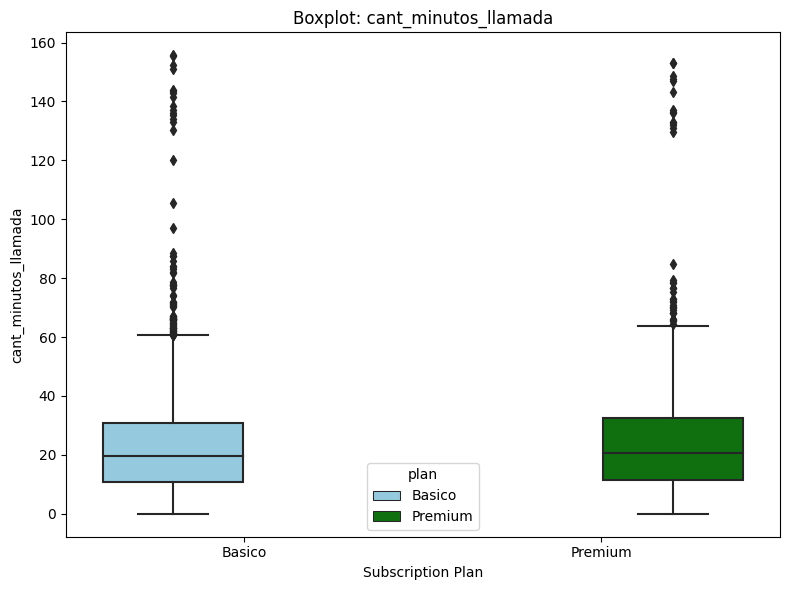

In [49]:
cols_to_plot = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
palette = {'Basico': 'skyblue', 'Premium': 'green'}
for col in cols_to_plot:
    plt.figure(figsize=(8, 6))
    
    sns.boxplot(
        data=user_profile, # Using your df name from the traceback
        x='plan', 
        y=col, 
        palette=palette,
        hue='plan'
    )
    
    plt.title(f'Boxplot: {col}')
    plt.ylabel(col)
    plt.xlabel('Subscription Plan')
    
    plt.tight_layout()
    plt.show()

💡Insights: 
- Age: no presenta outliers
- cant_mensajes: Presenta pocos outliers para ambos planes, con distrubucion similar entre basico y premium.
- cant_llamadas: Cntidad de llamadas presenta muy pocos outliers, con mayor cantidad y separacion en el plan basico y un solo outlier seca del limite superior en el plan primum. 
- cant_minutos_llamada: presenta una cantidad significativa de outliers en ambos planes muy superiro al limite superior.

In [52]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    # Calcular Quartiles
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    # Calcular IQR
    IQR = Q3 - Q1

    # Definir Limite Superiro
    upper_limit = Q3 + 1.5 * IQR

    print(f"Columna: {col}")
    print(f"Limite Superiro: {upper_limit}")
    print()

Columna: cant_mensajes
Limite Superiro: 11.5

Columna: cant_llamadas
Limite Superiro: 10.5

Columna: cant_minutos_llamada
Limite Superiro: 61.8575



In [53]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener outliers ya que tiene pocoa variasion sobre el limite superion con numeros realistas
- cant_llamadas: mantener outliers ya que tiene pocoa variasion sobre el limite superion con numeros realistas
- cant_minutos_llamada: mantener outliers, aunque esta cola sesga los valores de promedio son valores seales que representa patrones de uso. Considerar la mediana para valor intermedio. 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [56]:

# Logica de condisiones
def categorizar_uso(row):
    # Condision 1: Bajo Uso
    if row['cant_mensajes'] < 5 and row['cant_llamadas'] < 5:
        return 'bajo uso'
    # Condision 2: Uso Medio
    elif row['cant_mensajes'] < 10 and row['cant_llamadas'] < 10:
        return 'uso medio'
    # Condision 3: Lo restante
    else:
        return 'uso alto'

# Crear columna grupo_uso
user_profile['grupo_uso'] = user_profile.apply(categorizar_uso, axis=1)


In [57]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,uso alto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,uso alto
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [58]:

# Logica de condisiones
def categorizar_uso(row):
    # Condision 1: Segmentasion de Jovenes
    if row['age'] < 30:
        return 'Joven'
    # Condision 2: Segmentacion de Adultos
    elif row['age'] < 60:
        return 'Adulto'
    # Condision 3: Lo restante
    else:
        return 'Adulto Mayor'

# Crear columna grupo_edad
user_profile['grupo_edad'] = user_profile.apply(categorizar_uso, axis=1)


In [59]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,uso alto,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,uso alto,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

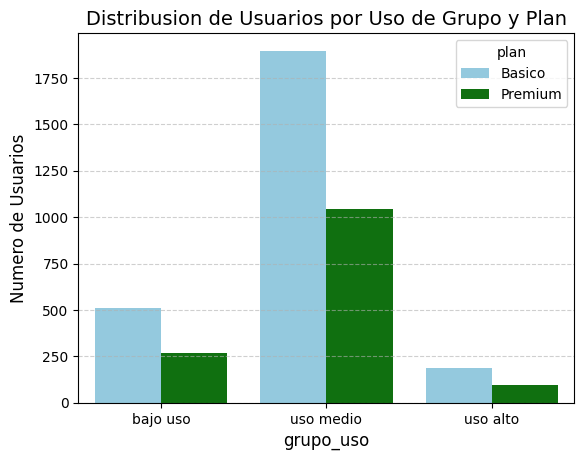

In [62]:

# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile, 
    x='grupo_uso', 
    hue='plan', 
    order=['bajo uso', 'uso medio', 'uso alto'], 
    palette={'Basico': 'skyblue', 'Premium': 'green'}
)

# Agregar labels y titulo
plt.title('Distribusion de Usuarios por Uso de Grupo y Plan', fontsize=14)
plt.xlabel('grupo_uso', fontsize=12)
plt.ylabel('Numero de Usuarios', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()


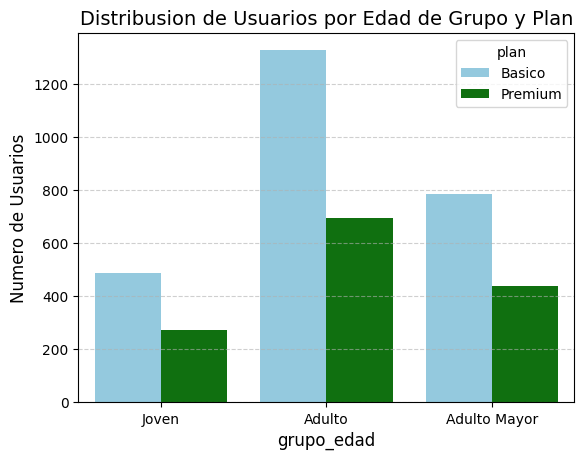

In [63]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile, 
    x='grupo_edad', 
    hue='plan', 
    order=['Joven', 'Adulto', 'Adulto Mayor'], 
    palette={'Basico': 'skyblue', 'Premium': 'green'}
)

# Agregar labels y titulo
plt.title('Distribusion de Usuarios por Edad de Grupo y Plan', fontsize=14)
plt.xlabel('grupo_edad', fontsize=12)
plt.ylabel('Numero de Usuarios', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()


---
## 🧩Paso 8: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

* **Valores Nulos:**
    * **`users.churn_date` (88.35%):** Indica que la gran mayoría de la base de clientes en 2024 permanece activa; es un valor esperado.
    * **`users.city` (11.73%):** Ausencia de datos geográficos que se categorizan como "Desconocido" sin impactar la métrica global.
    * **`usage.duration` (55.19%) y `usage.length` (44.74%):** Nulos estructurales que corresponden a la naturaleza del servicio (llamadas vs. mensajes); se validan como registros correctos.
* **Inconsistencias y Calidad:**
    * **Edad:** Presencia de registros con el valor `-999`. Se requiere limpieza para no sesgar los promedios de los segmentos.
    * **Rango Temporal:** Se identificaron fechas fuera de rango (2026), por lo que el análisis se acota exclusivamente al periodo **2024** para asegurar la integridad de los resultados.

🔍 **Segmentos por Edad**
* Se detecta una distribución equilibrada de usuarios entre 18 y 79 años, con un repunte visible en el rango de **45 a 50 años**.
* La población se divide en tres grupos clave: **Jóvenes** (menores a 30), **Adultos** (30 a 60) y **Adultos Mayores** (más de 60).
* Se identifica que el volumen principal de la cartera pertenece al grupo de **Adultos**.

📊 **Segmentos por Nivel de Uso**
* Tanto el uso de mensajes como el de llamadas presentan una distribución con **sesgo a la derecha**.
* Aunque existen valores extremos, estos representan una fracción mínima de la población, por lo que el comportamiento operativo real se concentra en los rangos estándar.
* Se segmenta en: **Uso Bajo** (menos de 5 llamadas/mensajes), **Uso Medio** (entre 5 y 10) y **Uso Alto** (más de 10).
* Se identifica que la mayoría de los usuarios se encuentran en el grupo de **Uso Medio**.

➡️ Esto sugiere que el perfil predominante y de mayor estabilidad para ConnectaTel es el de **Adultos (30-60 años)** con un **Uso Medio** de los servicios. La relación entre estos dos factores indica una base de clientes madura con consumos predecibles.

💡 **Recomendaciones**
* **Enfoque Estratégico:** Priorizar los esfuerzos comerciales en el sector de 30 a 60 años. Al ser el segmento mayoritario con consumo moderado, representan el menor riesgo de deserción y la mayor oportunidad de ingresos estables.
* **Fidelización:** Desarrollar campañas de lealtad diseñadas para mantener el consumo en el rango de "Uso Medio", evitando la migración a "Uso Bajo" mediante paquetes que incentiven el uso balanceado de voz y datos.
* **Crecimiento Orgánico:** Dado que la mayoría ya posee un consumo predecible, se recomienda crear ofertas que faciliten ligeros incrementos en su nivel de uso actual sin necesidad de planes disruptivos.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`